In [33]:
import pandas as pd
import numpy as np
import random
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime,timedelta
import platform

if platform.system() =='Darwin' : plt.rc('font',family='AppleGothic')
elif platform.system() =='Windows' : plt.rc('font',family='Malgun Gothic')
else : plt.rc('font',family='DejaVu Sans')
plt.rcParams['axes.unicode_minus']=False

conn=sqlite3.connect(':memory:')
AUTH_KEY="002d14c0f2b78344ad5e100d8ba4d7140142c4782899795912c6aee594e03097"

In [34]:
def fetch_and_load_data(key):
    endpoint="https://api.odcloud.kr/api/15083033/v1/uddi:c7049f5a-d95e-4143-be96-b4d3c16130ee"
    params={'page' : 1, 'perPage' :100, 'serviceKey': key}

    try:
        res=requests.get(endpoint,params=params,timeout=5)
        if res.status_code==200:
            data=res.json().get('data',[])
            if not data:raise Exception("No Data")
            df_cafes=pd.DataFrame(data)
            df_cafes=df_cafes.iloc[:,:3]
            df_cafes.columns=['bizesId','bizesNm','rdnmAdr']
            print(f"API 데이터 수집 성공({len(df_cafes)}개)")

        else:
            raise Exception("API Key or Server Error")

    except Exception as e:
        print("API 대신 가상 매장 데이터를 생성했습니다. (사유 : {e})")
        df_cafes=pd.DataFrame({
            'bizesId' : [f"CAFE_{i:03d}" for i in range(1,21)],
            'bizesNm' : ['스타벅스 강남점','투썸플레이스','이디야','블루보틀 역삼','폴바셋']*4,
            'rdnmAdr' : [f"강난구 테헤란로 {i}길" for i in range(1,21)]
        })
        print("API 대신 가상 매장 데이터를 생성했습니다.")
    num_users=500
    u_ids=[f"U_{i:04d}" for i in range(1,num_users+1)]
    channels=['Instagram','Google_Ads','YouTube','Organic']
    df_users=pd.DataFrame({
        'user_id':u_ids,
        'signup_date':[datetime(2025,1,1)+timedelta(days=random.randint(0,100))for _ in range(num_users)],
        'channel' : [random.choice(channels) for _ in range(num_users)]
    })

    orders=[]
    cafe_ids=df_cafes['bizesId'].tolist()
    for _ in range(7000):
        uid=random.choice(u_ids)
        sid=random.choice(cafe_ids)
        sdt=pd.to_datetime(df_users.loc[df_users['user_id']==uid,'signup_date'].values[0])
        sdt=pd.to_datetime(sdt)
        odt=sdt+timedelta(days=random.randint(0,180),hours=random.randint(7,14))
        orders.append([uid,sid,odt,random.choice([4500,5500,12000,15000])])

    df_orders=pd.DataFrame(orders,columns=['user_id','store_id','order_at','amount'])

    df_cafes.to_sql('raw_cafes',conn,index=False,if_exists='replace')
    df_users.to_sql('raw_users',conn,index=False,if_exists='replace')
    df_orders.to_sql('raw_orders',conn,index=False,if_exists='replace')
    return "데이터 적재 완료"

print(fetch_and_load_data(AUTH_KEY))

API 데이터 수집 성공(100개)
데이터 적재 완료


In [37]:
query_retention="""
With user_first_order AS(
    SELECT user_id,MIN(order_at) as first_order
    FROM raw_orders
    GROUP BY user_id
),
cohort_base AS(
    SELECT
        o.user_id,
        strftime('%Y-%m', f.first_order) as cohort_month,
        CAST(strftime('%Y', f.first_order) AS INT) as first_year,
        CAST(strftime('%m', f.first_order) AS INT) as first_month,
        CAST(strftime('%Y', o.order_at) AS INT) as order_year,
        CAST(strftime('%m', o.order_at) AS INT) as order_month
    FROM raw_orders o
    JOIN user_first_order f ON o.user_id=f.user_id
)

SELECT
    cohort_month,
    (order_year - first_year) * 12 + (order_month - first_month) as month_dist,
    COUNT(DISTINCT user_id) as user_cnt
FROM cohort_base
GROUP BY 1,2
ORDER BY 1,2
"""

mart_retention=pd.read_sql_query(query_retention,conn)

query_marketing="""
SELECT
    u.channel,
    COUNT(DISTINCT u.user_id) as new_users,
    COALESCE(SUM(o.amount),0) as total_revenue
FROM raw_users u
LEFT JOIN raw_orders o ON u.user_id=o.user_id
GROUP BY 1
"""

mart_marketing=pd.read_sql_query(query_marketing,conn)
print("SQL 데이터 마트 생성 완료")

SQL 데이터 마트 생성 완료


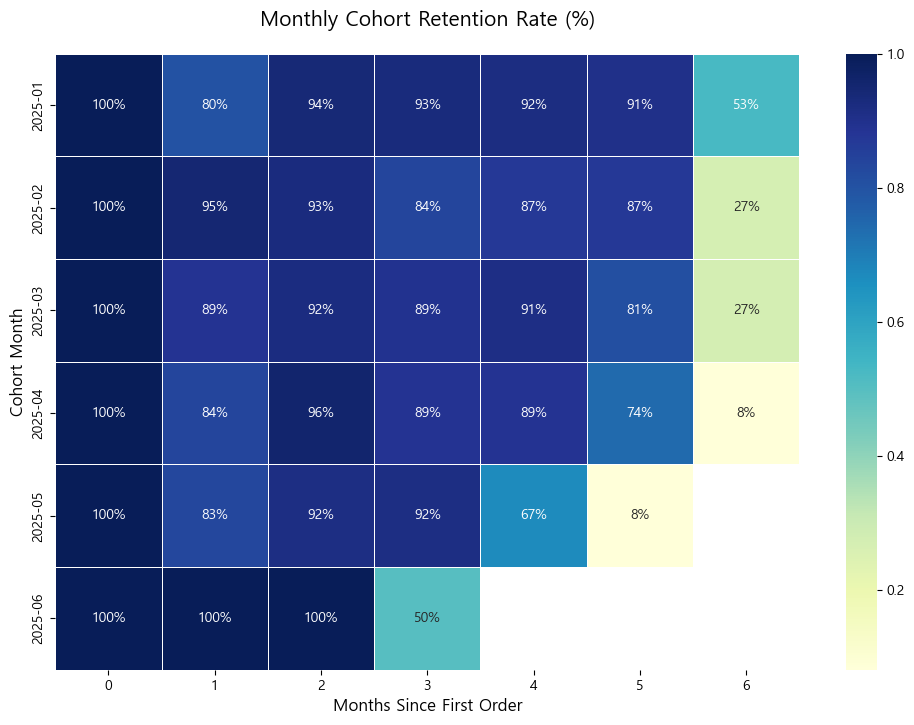

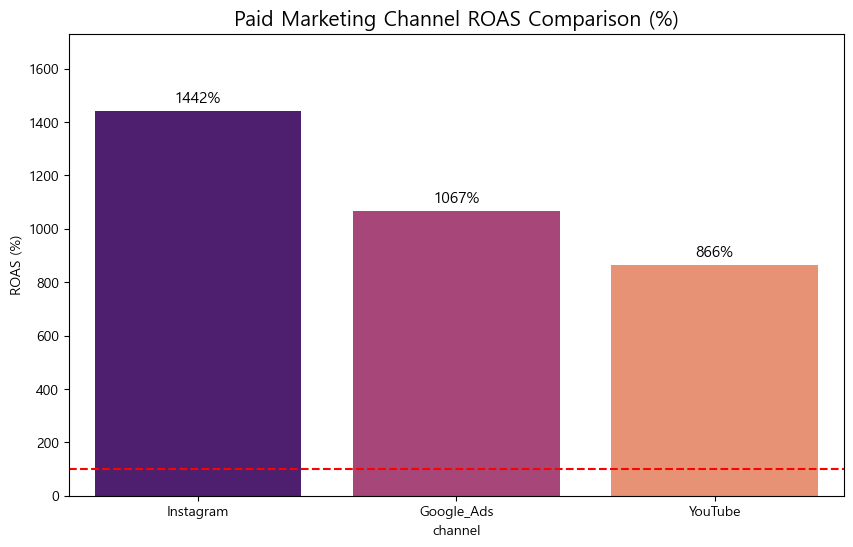


### [최종] 마케팅 유료 채널 효율 보고서 ###


,channel,total_revenue,spend,ROAS
1,Instagram,14422500,1000000,1442.250000
0,Google_Ads,16006000,1500000,1067.066667
3,YouTube,17322000,2000000,866.100000


In [40]:
mart_retention['month_dist']=mart_retention['month_dist'].astype(int)
mart_retention['cohort_month']=mart_retention['cohort_month'].astype(str)

retention_pivot=mart_retention.pivot(index='cohort_month',columns='month_dist',values='user_cnt')

retention_rate=retention_pivot.divide(retention_pivot.iloc[:,0],axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(retention_rate,
            annot=True,
            fmt='.0%',
            cmap='YlGnBu',
            linewidths=.5)

plt.title('Monthly Cohort Retention Rate (%)',fontsize=15,pad=20)
plt.xlabel('Months Since First Order',fontsize=12)
plt.ylabel('Cohort Month',fontsize=12)
plt.show()

paid_marketing=mart_marketing[mart_marketing['channel'] != 'Organic'].copy()

costs={'Instagram':1000000,'Google_Ads':1500000,'YouTube':2000000,'Organic':1}
paid_marketing['spend']=mart_marketing['channel'].map(costs)
paid_marketing['ROAS']=(mart_marketing['total_revenue']/mart_marketing['spend'])*100

plt.figure(figsize=(10, 6))
# [수정] Future Warning 방지를 위해 x를 hue에 할당
ax = sns.barplot(data=paid_marketing.sort_values('ROAS', ascending=False), 
                 x='channel', y='ROAS', hue='channel', palette='magma', legend=False)

# 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11)

plt.axhline(100, color='red', linestyle='--', label='Break-even (100%)')
plt.title('Paid Marketing Channel ROAS Comparison (%)', fontsize=15)
plt.ylabel('ROAS (%)')
plt.ylim(0, paid_marketing['ROAS'].max() * 1.2) # 여유 공간 확보
plt.show()

# 최종 리포트 출력
print("\n" + "="*50)
print("### [최종] 마케팅 유료 채널 효율 보고서 ###")
print("="*50)
display(paid_marketing[['channel', 'total_revenue', 'spend', 'ROAS']].sort_values('ROAS', ascending=False))

In [ ]:
import pandas as pd
import numpy as np
import random
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime,timedelta
import platform

if platform.system() =='Darwin' : plt.rc('font',family='AppleGothic')
elif platform.system() =='Windows' : plt.rc('font',family='Malgun Gothic')
else : plt.rc('font',family='DejaVu Sans')
plt.rcParams['axes.unicode_minus']=False

conn=sqlite3.connect(':memory:')
AUTH_KEY="002d14c0f2b78344ad5e100d8ba4d7140142c4782899795912c6aee594e03097"

def fetch_and_load_data(key):
    endpoint="https://api.odcloud.kr/api/15083033/v1/uddi:c7049f5a-d95e-4143-be96-b4d3c16130ee"
    params={'page' : 1, 'perPage' :100, 'serviceKey': key}

    try:
        res=requests.get(endpoint,params=params,timeout=5)
        if res.status_code==200:
            data=res.json().get('data',[])
            if not data:raise Exception("No Data")
            df_cafes=pd.DataFrame(data)
            df_cafes=df_cafes.iloc[:,:3]
            df_cafes.columns=['bizesId','bizesNm','rdnmAdr']
            print(f"API 데이터 수집 성공({len(df_cafes)}개)")

        else:
            raise Exception("API Key or Server Error")

    except Exception as e:
        print("API 대신 가상 매장 데이터를 생성했습니다. (사유 : {e})")
        df_cafes=pd.DataFrame({
            'bizesId' : [f"CAFE_{i:03d}" for i in range(1,21)],
            'bizesNm' : ['스타벅스 강남점','투썸플레이스','이디야','블루보틀 역삼','폴바셋']*4,
            'rdnmAdr' : [f"강난구 테헤란로 {i}길" for i in range(1,21)]
        })
        print("API 대신 가상 매장 데이터를 생성했습니다.")
    num_users=500
    u_ids=[f"U_{i:04d}" for i in range(1,num_users+1)]
    channels=['Instagram','Google_Ads','YouTube','Organic']
    df_users=pd.DataFrame({
        'user_id':u_ids,
        'signup_date':[datetime(2025,1,1)+timedelta(days=random.randint(0,100))for _ in range(num_users)],
        'channel' : [random.choice(channels) for _ in range(num_users)]
    })

    orders=[]
    cafe_ids=df_cafes['bizesId'].tolist()
    for _ in range(7000):
        uid=random.choice(u_ids)
        sid=random.choice(cafe_ids)
        sdt=pd.to_datetime(df_users.loc[df_users['user_id']==uid,'signup_date'].values[0])
        sdt=pd.to_datetime(sdt)
        odt=sdt+timedelta(days=random.randint(0,180),hours=random.randint(7,14))
        orders.append([uid,sid,odt,random.choice([4500,5500,12000,15000])])

    df_orders=pd.DataFrame(orders,columns=['user_id','store_id','order_at','amount'])

    df_cafes.to_sql('raw_cafes',conn,index=False,if_exists='replace')
    df_users.to_sql('raw_users',conn,index=False,if_exists='replace')
    df_orders.to_sql('raw_orders',conn,index=False,if_exists='replace')
    return "데이터 적재 완료"

print(fetch_and_load_data(AUTH_KEY))

query_retention="""
With user_first_order AS(
    SELECT user_id,MIN(order_at) as first_order
    FROM raw_orders
    GROUP BY user_id
),
cohort_base AS(
    SELECT
        o.user_id,
        strftime('%Y-%m', f.first_order) as cohort_month,
        CAST(strftime('%Y', f.first_order) AS INT) as first_year,
        CAST(strftime('%m', f.first_order) AS INT) as first_month,
        CAST(strftime('%Y', o.order_at) AS INT) as order_year,
        CAST(strftime('%m', o.order_at) AS INT) as order_month
    FROM raw_orders o
    JOIN user_first_order f ON o.user_id=f.user_id
)

SELECT
    cohort_month,
    (order_year - first_year) * 12 + (order_month - first_month) as month_dist,
    COUNT(DISTINCT user_id) as user_cnt
FROM cohort_base
GROUP BY 1,2
ORDER BY 1,2
"""

mart_retention=pd.read_sql_query(query_retention,conn)

query_marketing="""
SELECT
    u.channel,
    COUNT(DISTINCT u.user_id) as new_users,
    COALESCE(SUM(o.amount),0) as total_revenue
FROM raw_users u
LEFT JOIN raw_orders o ON u.user_id=o.user_id
GROUP BY 1
"""

mart_marketing=pd.read_sql_query(query_marketing,conn)
print("SQL 데이터 마트 생성 완료")

mart_retention['month_dist']=mart_retention['month_dist'].astype(int)
mart_retention['cohort_month']=mart_retention['cohort_month'].astype(str)

retention_pivot=mart_retention.pivot(index='cohort_month',columns='month_dist',values='user_cnt')

retention_rate=retention_pivot.divide(retention_pivot.iloc[:,0],axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(retention_rate,
            annot=True,
            fmt='.0%',
            cmap='YlGnBu',
            linewidths=.5)

plt.title('Monthly Cohort Retention Rate (%)',fontsize=15,pad=20)
plt.xlabel('Months Since First Order',fontsize=12)
plt.ylabel('Cohort Month',fontsize=12)
plt.show()

paid_marketing=mart_marketing[mart_marketing['channel'] != 'Organic'].copy()

costs={'Instagram':1000000,'Google_Ads':1500000,'YouTube':2000000,'Organic':1}
paid_marketing['spend']=mart_marketing['channel'].map(costs)
paid_marketing['ROAS']=(mart_marketing['total_revenue']/mart_marketing['spend'])*100

plt.figure(figsize=(10, 6))
# [수정] Future Warning 방지를 위해 x를 hue에 할당
ax = sns.barplot(data=paid_marketing.sort_values('ROAS', ascending=False), 
                 x='channel', y='ROAS', hue='channel', palette='magma', legend=False)

# 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11)

plt.axhline(100, color='red', linestyle='--', label='Break-even (100%)')
plt.title('Paid Marketing Channel ROAS Comparison (%)', fontsize=15)
plt.ylabel('ROAS (%)')
plt.ylim(0, paid_marketing['ROAS'].max() * 1.2) # 여유 공간 확보
plt.show()

# 최종 리포트 출력
print("\n" + "="*50)
print("### [최종] 마케팅 유료 채널 효율 보고서 ###")
print("="*50)
display(paid_marketing[['channel', 'total_revenue', 'spend', 'ROAS']].sort_values('ROAS', ascending=False))